In [5]:
!pip install gymnasium[box2d] torch numpy matplotlib

  Using cached box2d-py-2.3.5.tar.gz (374 kB)
  Preparing metadata (setup.py) ... done
  Using cached swig-4.4.1-py3-none-manylinux_2_12_x86_64.manylinux2010_x86_64.whl.metadata (3.5 kB)
  Using cached cuda_bindings-12.9.4-cp312-cp312-manylinux_2_24_x86_64.manylinux_2_28_x86_64.whl.metadata (2.6 kB)
Using cached swig-4.4.1-py3-none-manylinux_2_12_x86_64.manylinux2010_x86_64.whl (1.9 MB)
Using cached cuda_bindings-12.9.4-cp312-cp312-manylinux_2_24_x86_64.manylinux_2_28_x86_64.whl (12.2 MB)
  error: subprocess-exited-with-error
  
  × python setup.py bdist_wheel did not run successfully.
  │ exit code: 1
  ╰─> See above for output.
  
  note: This error originates from a subprocess, and is likely not a problem with pip.
  ERROR: Failed building wheel for box2d-py
  Running setup.py clean for box2d-py
Failed to build box2d-py
ERROR: ERROR: Failed to build installable wheels for some pyproject.toml based projects (box2d-py)


In [9]:
pip install swig
pip install "gymnasium[box2d]"

  Using cached swig-4.4.1-py3-none-manylinux_2_12_x86_64.manylinux2010_x86_64.whl.metadata (3.5 kB)
Using cached swig-4.4.1-py3-none-manylinux_2_12_x86_64.manylinux2010_x86_64.whl (1.9 MB)
Note: you may need to restart the kernel to use updated packages.


In [10]:
pip install "gymnasium[box2d]"

  Using cached box2d-py-2.3.5.tar.gz (374 kB)
  Preparing metadata (setup.py) ... done
  Created wheel for box2d-py: filename=box2d_py-2.3.5-cp312-cp312-linux_x86_64.whl size=2398776 sha256=542f8188e7d539dceba03352f82ab1a21ab96bd3ce214799fc0eca3232d39ccf
  Stored in directory: /root/.cache/pip/wheels/2a/e9/60/774da0bcd07f7dc7761a8590fa2d065e4069568e78dcdc3318
Successfully built box2d-py
Note: you may need to restart the kernel to use updated packages.


In [11]:
import numpy as np
import gymnasium as gym
import torch
from torch import nn, optim
import torch.nn.functional as F
import random
from collections import deque
import copy

# Plot Functions

In [15]:
import matplotlib.pyplot as plt

def moving_average(x, w):
    return np.convolve(x, np.ones(w), 'valid') / w

def moving_std(x, w):
    return np.array([
        np.std(x[i:i+w]) if i + w <= len(x) else np.std(x[i:])
        for i in range(len(x) - w + 1)
    ])

def plot_smoothed(ax, data, window, color, title, xlabel, ylabel):
    data = np.array(data)
    if len(data) >= window:
        x      = np.arange(window - 1, len(data))
        smooth = moving_average(data, window)
        std    = moving_std(data, window)
        ax.plot(data, color=color, alpha=0.15, linewidth=0.8, label='Raw')
        ax.plot(x, smooth, color=color, linewidth=2, label=f'MA({window})')
        ax.fill_between(x, smooth - std, smooth + std, color=color, alpha=0.2, label='±1 std')
    else:
        ax.plot(data, color=color, linewidth=1.5)
    ax.set_title(title)
    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)
    ax.legend()
    ax.grid(True, alpha=0.3)

def plot_training(losses, rewards, lengths=None, window=50):
    n = 3 if lengths is not None else 2
    fig, axes = plt.subplots(1, n, figsize=(7 * n, 5))

    plot_smoothed(axes[0], losses,  window, 'blue',
                   "Training Loss", "Update step", "Loss")
    plot_smoothed(axes[1], rewards, window, 'green',
                   "Reward per Episode", "Episode", "Total reward")
    if lengths is not None:
        plot_smoothed(axes[2], lengths, window, 'darkorange',
                       "Steps per Episode", "Episode", "Episode length")

    plt.suptitle("DQN Training - LunarLander", fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.show()

# DQN Agent

In [13]:
class DQN_MLP(nn.Module):
    def __init__(self, state_size, action_size):
        super(DQN_MLP, self).__init__()
        self.net = nn.Sequential(
            nn.Linear(state_size, 128),
            nn.ReLU(),
            nn.Linear(128, 128),
            nn.ReLU(),
            nn.Linear(128, action_size)
        )

    def forward(self, x):
        return self.net(x)


class DQNAgent:
    def __init__(self, state_size, action_size):
        self.state_size = state_size
        self.action_size = action_size
        self.memory = deque(maxlen=50000)
        self.gamma = 0.99                # descuento: valora recompensas futuras
        self.epsilon = 1.0               # exploración inicial: 100% aleatoria
        self.epsilon_min = 0.01          # exploración mínima residual
        self.epsilon_decay = 0.997       # factor de decaimiento por episodio
        self.learning_rate = 5e-3
        self.batch_size = 128
        self.target_update_freq = 5     # cada cuántos episodios se actualiza la target net
        self.steps_done = 0
        self.device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
        self.model = self._build_model()
        self.target_model = copy.deepcopy(self.model).to(self.device)
        self.target_model.eval()
        self.optimizer = optim.Adam(self.model.parameters(), lr=self.learning_rate)
        self.loss_fn = nn.MSELoss()


    def _build_model(self):
        model = DQN_MLP(self.state_size, self.action_size).to(self.device)
        return model

    def remember(self, state, action, reward, next_state, done):
        self.memory.append((state, action, reward, next_state, done))

    def select_action(self, state):
        if np.random.rand() <= self.epsilon:
            return random.randrange(self.action_size)
        state = torch.FloatTensor(state).unsqueeze(0).to(self.device)
        with torch.no_grad():
            act_values = self.model(state)
        return torch.argmax(act_values[0]).item()

    def replay(self):
        if len(self.memory) < self.batch_size:
            return None

        minibatch = random.sample(self.memory, self.batch_size)
        states      = torch.FloatTensor(np.array([e[0] for e in minibatch])).to(self.device)
        actions     = torch.LongTensor([e[1] for e in minibatch]).unsqueeze(1).to(self.device)
        rewards     = torch.FloatTensor([e[2] for e in minibatch]).to(self.device)
        next_states = torch.FloatTensor(np.array([e[3] for e in minibatch])).to(self.device)
        dones       = torch.FloatTensor([float(e[4]) for e in minibatch]).to(self.device)

        # Q(s, a) estimado por la red principal
        q_values = self.model(states).gather(1, actions).squeeze(1)

        # Target: r + gamma * max_a Q_target(s', a')  (0 si el episodio termino)
        with torch.no_grad():
            q_next   = self.target_model(next_states).max(1)[0]
            q_target = rewards + self.gamma * q_next * (1 - dones)

        loss = self.loss_fn(q_values, q_target)

        self.optimizer.zero_grad()
        loss.backward()
        self.optimizer.step()

        self.steps_done += 1

        # Decaer epsilon
        if self.epsilon > self.epsilon_min:
            self.epsilon *= self.epsilon_decay

        return loss.item()


def train_MLP_agent(env, episodes):
    agent = DQNAgent(state_size=8, action_size=4)
    losses = []
    rewards_hist = []
    lengths_hist = []

    for e in range(episodes):
        state, info = env.reset()
        done = False
        total_reward = 0
        total_steps = 0

        while not done:
            action = agent.select_action(state)
            next_state, reward, terminated, truncated, info = env.step(action)
            done = terminated or truncated
            agent.remember(state, action, reward, next_state, done)
            state = next_state

            total_steps += 1
            total_reward += reward

            loss = agent.replay()
            if loss is not None:
                losses.append(loss)

        # Actualizar target network cada target_update_freq episodios
        if (e + 1) % agent.target_update_freq == 0:
            agent.target_model.load_state_dict(agent.model.state_dict())

        rewards_hist.append(total_reward)
        lengths_hist.append(total_steps)
        avg_reward = np.mean(rewards_hist[-50:])
        print(f"Ep {e+1:4d} | Reward: {total_reward:8.1f} | Ep Total Steps: {total_steps:4d} | Avg(50): {avg_reward:8.1f} | ε: {agent.epsilon:.3f}")

    return agent, losses, rewards_hist, lengths_hist

In [14]:
pip install swig 

Note: you may need to restart the kernel to use updated packages.


In [15]:
pip install "gymnasium[box2d]" 

Note: you may need to restart the kernel to use updated packages.


In [16]:
environment = gym.make("LunarLander-v3", continuous=False, gravity=-10.0,
               enable_wind=True, wind_power=15.0, turbulence_power=1.5)

agent, losses, rewards_hist, lengths_hist = train_MLP_agent(env=environment, episodes=1000)

Ep    1 | Reward:   -419.5 | Ep Total Steps:   88 | Avg(50):   -419.5 | ε: 1.000
Ep    2 | Reward:   -442.2 | Ep Total Steps:  108 | Avg(50):   -430.9 | ε: 0.813
Ep    3 | Reward:   -311.3 | Ep Total Steps:  105 | Avg(50):   -391.0 | ε: 0.593
Ep    4 | Reward:   -129.5 | Ep Total Steps:   63 | Avg(50):   -325.6 | ε: 0.491
Ep    5 | Reward:   -195.1 | Ep Total Steps:  183 | Avg(50):   -299.5 | ε: 0.283
Ep    6 | Reward:   -500.2 | Ep Total Steps:  164 | Avg(50):   -333.0 | ε: 0.173
Ep    7 | Reward:   -331.8 | Ep Total Steps:   87 | Avg(50):   -332.8 | ε: 0.133
Ep    8 | Reward:   -471.8 | Ep Total Steps:  175 | Avg(50):   -350.2 | ε: 0.079
Ep    9 | Reward:   -386.9 | Ep Total Steps:  168 | Avg(50):   -354.3 | ε: 0.048
Ep   10 | Reward:   -102.2 | Ep Total Steps:  259 | Avg(50):   -329.1 | ε: 0.022
Ep   11 | Reward:   -124.1 | Ep Total Steps:  183 | Avg(50):   -310.4 | ε: 0.013
Ep   12 | Reward:   -293.8 | Ep Total Steps:  314 | Avg(50):   -309.0 | ε: 0.010
Ep   13 | Reward:   -148.9 |

# Evaluation

In [17]:
from gymnasium.wrappers import RecordVideo

def evaluate_agent(agent, env_name="LunarLander-v3", num_episodes=5, save_dir="videos", render_video=True):

    agent.epsilon = 0.0

    if render_video:
        env = gym.make(env_name, continuous=False, gravity=-10.0, enable_wind=True,
                       wind_power=15.0, turbulence_power=1.5, render_mode="rgb_array")
        env = RecordVideo(
            env,
            video_folder=save_dir,
            episode_trigger=lambda ep: True,
            name_prefix="lunarlander_eval"
        )
    else:
        env = gym.make(env_name)

    rewards = []
    successes = 0

    for ep in range(num_episodes):
        state, _ = env.reset()
        done = False
        total_reward = 0
        steps = 0

        while not done:
            action = agent.select_action(state)
            next_state, reward, terminated, truncated, _ = env.step(action)
            done = terminated or truncated
            state = next_state
            total_reward += reward
            steps += 1

        rewards.append(total_reward)

        if total_reward >= 200:
            successes += 1

        print(f"Episodio {ep+1:3d} | Reward: {total_reward:8.1f} | Steps: {steps:4d} | {'Logrado' if total_reward >= 200 else 'No Logrado'}")

    env.close()

    print(f"Episodios evaluados: {num_episodes}")
    print(f"Éxitos (reward≥200): {successes}/{num_episodes} ({100*successes/num_episodes:.0f}%)")
    print(f"Reward promedio: {np.mean(rewards):.1f}")
    print(f"Reward máximo: {np.max(rewards):.1f}")
    print(f"Reward mínimo: {np.min(rewards):.1f}")
    if render_video:
        print(f"Videos guardados en: {save_dir}/")

    return rewards, np.mean(rewards), successes / num_episodes

In [19]:
rewards, mean_reward, success_rate = evaluate_agent(
    agent=agent,
    env_name="LunarLander-v3",
    num_episodes=10,
    save_dir="test_DQN",
    render_video=False  # <- asegúrate que esté esto
)

Episodio   1 | Reward:   -184.4 | Steps:  197 | No Logrado
Episodio   2 | Reward:    297.1 | Steps:  239 | Logrado
Episodio   3 | Reward:    239.9 | Steps:  190 | Logrado
Episodio   4 | Reward:    220.9 | Steps:  234 | Logrado
Episodio   5 | Reward:      7.0 | Steps: 1000 | No Logrado
Episodio   6 | Reward:   -177.8 | Steps:  193 | No Logrado
Episodio   7 | Reward:    216.2 | Steps:  246 | Logrado
Episodio   8 | Reward:    -73.1 | Steps:  180 | No Logrado
Episodio   9 | Reward:    -90.4 | Steps:  101 | No Logrado
Episodio  10 | Reward:    245.8 | Steps:  194 | Logrado
Episodios evaluados: 10
Éxitos (reward≥200): 5/10 (50%)
Reward promedio: 70.1
Reward máximo: 297.1
Reward mínimo: -184.4


# Figures

/usr/local/lib/python3.12/dist-packages/gymnasium/wrappers/rendering.py:432: UserWarning: WARN: Unable to save last video! Did you call close()?
  logger.warn("Unable to save last video! Did you call close()?")


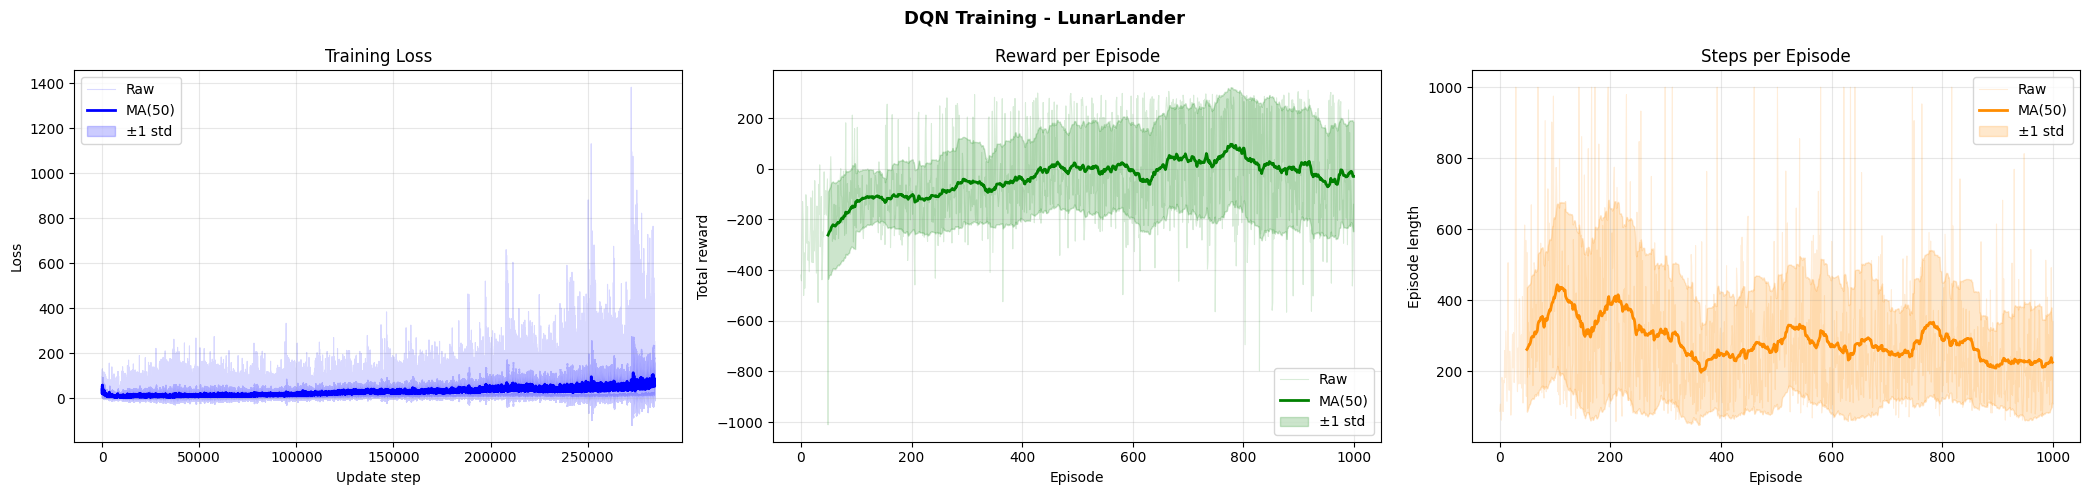

In [20]:
plot_training(losses, rewards_hist, lengths_hist, window=50)

In [14]:
# ablation study 

# ============================================================
# ABLATION STUDY - DQN
# Agrega estas celdas al FINAL del notebook HW3_DQN_agent.ipynb
# ============================================================

# ---- Celda 1: función de entrenamiento modificada ----

def train_MLP_agent_ablation(env, episodes, agent):
    """Igual que train_MLP_agent pero recibe un agente ya configurado."""
    losses = []
    rewards_hist = []
    lengths_hist = []

    for e in range(episodes):
        state, info = env.reset()
        done = False
        total_reward = 0
        total_steps = 0

        while not done:
            action = agent.select_action(state)
            next_state, reward, terminated, truncated, info = env.step(action)
            done = terminated or truncated
            agent.remember(state, action, reward, next_state, done)
            state = next_state

            total_steps += 1
            total_reward += reward

            loss = agent.replay()
            if loss is not None:
                losses.append(loss)

        if (e + 1) % agent.target_update_freq == 0:
            agent.target_model.load_state_dict(agent.model.state_dict())

        rewards_hist.append(total_reward)
        lengths_hist.append(total_steps)

    return losses, rewards_hist, lengths_hist


# ---- Celda 2: ablation sobre epsilon_decay ----

print("=" * 60)
print("ABLATION 1: epsilon_decay")
print("=" * 60)

EPISODES_ABL = 400  # episodios por experimento (corto para que sea rápido)
resultados_epsilon = {}

for decay in [0.990, 0.995, 0.999]:
    env_abl = gym.make("LunarLander-v3", continuous=False, gravity=-10.0,
                       enable_wind=True, wind_power=15.0, turbulence_power=1.5)
    agent_abl = DQNAgent(state_size=8, action_size=4)
    agent_abl.epsilon_decay = decay  # solo este cambia

    _, rewards_abl, _ = train_MLP_agent_ablation(env_abl, EPISODES_ABL, agent_abl)
    env_abl.close()

    avg_final = np.mean(rewards_abl[-50:])
    resultados_epsilon[decay] = avg_final
    print(f"epsilon_decay = {decay} → Avg(50) final: {avg_final:.1f}")

print()


# ---- Celda 3: ablation sobre batch_size ----

print("=" * 60)
print("ABLATION 2: batch_size")
print("=" * 60)

resultados_batch = {}

for bs in [32, 64, 128]:
    env_abl = gym.make("LunarLander-v3", continuous=False, gravity=-10.0,
                       enable_wind=True, wind_power=15.0, turbulence_power=1.5)
    agent_abl = DQNAgent(state_size=8, action_size=4)
    agent_abl.batch_size = bs  # solo este cambia

    _, rewards_abl, _ = train_MLP_agent_ablation(env_abl, EPISODES_ABL, agent_abl)
    env_abl.close()

    avg_final = np.mean(rewards_abl[-50:])
    resultados_batch[bs] = avg_final
    print(f"batch_size = {bs:3d} → Avg(50) final: {avg_final:.1f}")

print()


# ---- Celda 4: ablation sobre target_update_freq ----

print("=" * 60)
print("ABLATION 3: target_update_freq")
print("=" * 60)

resultados_target = {}

for freq in [5, 10, 20]:
    env_abl = gym.make("LunarLander-v3", continuous=False, gravity=-10.0,
                       enable_wind=True, wind_power=15.0, turbulence_power=1.5)
    agent_abl = DQNAgent(state_size=8, action_size=4)
    agent_abl.target_update_freq = freq  # solo este cambia

    _, rewards_abl, _ = train_MLP_agent_ablation(env_abl, EPISODES_ABL, agent_abl)
    env_abl.close()

    avg_final = np.mean(rewards_abl[-50:])
    resultados_target[freq] = avg_final
    print(f"target_update_freq = {freq:2d} → Avg(50) final: {avg_final:.1f}")

print()


# ---- Celda 5: gráfico resumen del ablation ----

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Epsilon decay
axes[0].bar([str(k) for k in resultados_epsilon.keys()],
            list(resultados_epsilon.values()), color='steelblue')
axes[0].axhline(200, color='red', linestyle='--', label='Umbral éxito')
axes[0].set_title("Ablation: epsilon_decay")
axes[0].set_xlabel("epsilon_decay")
axes[0].set_ylabel("Avg(50) final")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Batch size
axes[1].bar([str(k) for k in resultados_batch.keys()],
            list(resultados_batch.values()), color='seagreen')
axes[1].axhline(200, color='red', linestyle='--', label='Umbral éxito')
axes[1].set_title("Ablation: batch_size")
axes[1].set_xlabel("batch_size")
axes[1].set_ylabel("Avg(50) final")
axes[1].legend()
axes[1].grid(True, alpha=0.3)

# Target update freq
axes[2].bar([str(k) for k in resultados_target.keys()],
            list(resultados_target.values()), color='darkorange')
axes[2].axhline(200, color='red', linestyle='--', label='Umbral éxito')
axes[2].set_title("Ablation: target_update_freq")
axes[2].set_xlabel("target_update_freq")
axes[2].set_ylabel("Avg(50) final")
axes[2].legend()
axes[2].grid(True, alpha=0.3)

plt.suptitle("DQN Ablation Study - LunarLander", fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

# Resumen final
print("\nRESUMEN ABLATION DQN")
print("-" * 40)
print("epsilon_decay:")
for k, v in resultados_epsilon.items():
    print(f"  {k} → {v:.1f}")
print("batch_size:")
for k, v in resultados_batch.items():
    print(f"  {k:3d} → {v:.1f}")
print("target_update_freq:")
for k, v in resultados_target.items():
    print(f"  {k:2d} → {v:.1f}")

ABLATION 1: epsilon_decay
epsilon_decay = 0.99 → Avg(50) final: 65.4
epsilon_decay = 0.995 → Avg(50) final: -96.0
epsilon_decay = 0.999 → Avg(50) final: 14.5

ABLATION 2: batch_size
batch_size =  32 → Avg(50) final: -31.9
batch_size =  64 → Avg(50) final: -98.7
batch_size = 128 → Avg(50) final: 16.4

ABLATION 3: target_update_freq
target_update_freq =  5 → Avg(50) final: -197.8
target_update_freq = 10 → Avg(50) final: -61.6
target_update_freq = 20 → Avg(50) final: -89.0



NameError: name 'plt' is not defined

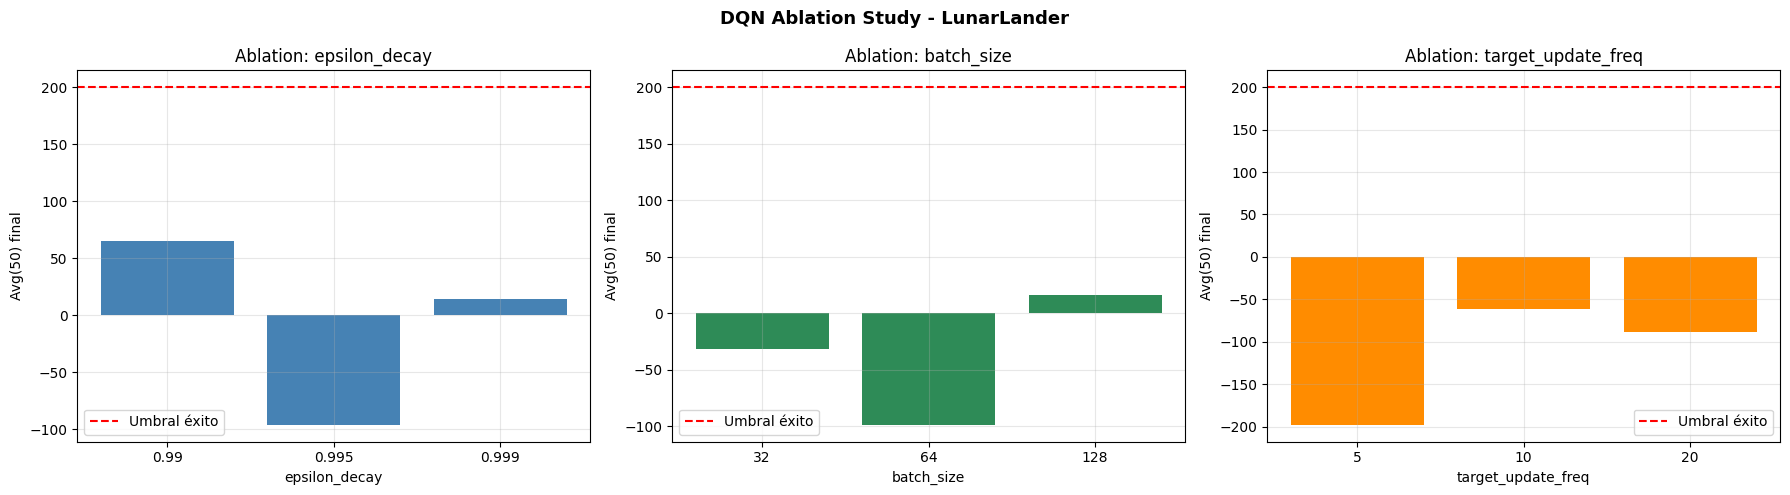


RESUMEN ABLATION DQN
----------------------------------------
epsilon_decay:
  0.99 → 65.4
  0.995 → -96.0
  0.999 → 14.5
batch_size:
   32 → -31.9
   64 → -98.7
  128 → 16.4
target_update_freq:
   5 → -197.8
  10 → -61.6
  20 → -89.0


In [16]:
# ---- Celda 5: gráfico resumen del ablation ----

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Epsilon decay
axes[0].bar([str(k) for k in resultados_epsilon.keys()],
            list(resultados_epsilon.values()), color='steelblue')
axes[0].axhline(200, color='red', linestyle='--', label='Umbral éxito')
axes[0].set_title("Ablation: epsilon_decay")
axes[0].set_xlabel("epsilon_decay")
axes[0].set_ylabel("Avg(50) final")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Batch size
axes[1].bar([str(k) for k in resultados_batch.keys()],
            list(resultados_batch.values()), color='seagreen')
axes[1].axhline(200, color='red', linestyle='--', label='Umbral éxito')
axes[1].set_title("Ablation: batch_size")
axes[1].set_xlabel("batch_size")
axes[1].set_ylabel("Avg(50) final")
axes[1].legend()
axes[1].grid(True, alpha=0.3)

# Target update freq
axes[2].bar([str(k) for k in resultados_target.keys()],
            list(resultados_target.values()), color='darkorange')
axes[2].axhline(200, color='red', linestyle='--', label='Umbral éxito')
axes[2].set_title("Ablation: target_update_freq")
axes[2].set_xlabel("target_update_freq")
axes[2].set_ylabel("Avg(50) final")
axes[2].legend()
axes[2].grid(True, alpha=0.3)

plt.suptitle("DQN Ablation Study - LunarLander", fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

# Resumen final
print("\nRESUMEN ABLATION DQN")
print("-" * 40)
print("epsilon_decay:")
for k, v in resultados_epsilon.items():
    print(f"  {k} → {v:.1f}")
print("batch_size:")
for k, v in resultados_batch.items():
    print(f"  {k:3d} → {v:.1f}")
print("target_update_freq:")
for k, v in resultados_target.items():
    print(f"  {k:2d} → {v:.1f}")